# 🤖 Modelagem — Comparação de classificadores

**CRISP-DM: fases 3-5 (Preparation, Modeling, Evaluation)**

Compara **Naive Bayes**, **Regressão Logística** e **SVM Linear** para classificação de sentimento (POSITIVO / NEUTRO / NEGATIVO).

In [15]:
import sys
sys.path.append('..')

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.models.train import train_all, load_data_from_db, load_data_from_csv, LABELS

sns.set_theme(style='whitegrid')

## 1. Carregar dados

In [16]:
try:
    df = load_data_from_db()
except Exception as e:
    print('Falha no DB, usando CSV:', e)
    from pathlib import Path
    csvs = sorted(Path('../data/raw').glob('reviews_*.csv'))
    df = load_data_from_csv(csvs[-1])

print(f'{len(df):,} reviews')
print(df['sentiment'].value_counts())

Falha no DB, usando CSV: (psycopg2.OperationalError) could not translate host name "db" to address: Name or service not known

(Background on this error at: https://sqlalche.me/e/20/e3q8)
3,000 reviews
sentiment
POSITIVO    2297
NEGATIVO     562
NEUTRO       141
Name: count, dtype: int64


## 2. Treinar e comparar

In [17]:
results = train_all(df)
print(json.dumps({k: v for k, v in results.items() if k != 'results'}, indent=2, ensure_ascii=False))

2026-09-22 14:55:03,967 | INFO | Distribuição de classes:
sentiment
POSITIVO    2297
NEGATIVO     562
NEUTRO       141
2026-09-22 14:55:03,970 | INFO | Treinando naive_bayes ...
2026-09-22 14:55:04,088 | INFO | naive_bayes | acc=0.8217  f1_macro=0.4713  roc_auc=0.7684
2026-09-22 14:55:04,088 | INFO | Treinando logistic_regression ...
2026-09-22 14:55:04,220 | INFO | logistic_regression | acc=0.7350  f1_macro=0.5010  roc_auc=0.7457
2026-09-22 14:55:04,220 | INFO | Treinando svm_linear ...
2026-09-22 14:55:04,366 | INFO | svm_linear | acc=0.8100  f1_macro=0.4562  roc_auc=0.7540
2026-09-22 14:55:04,374 | INFO | 🏆 Melhor modelo: logistic_regression (F1 macro = 0.5010)
2026-09-22 14:55:04,380 | INFO | Modelo salvo em C:\dev\sentiment-reviews\models\best_model.pkl
2026-09-22 14:55:04,387 | INFO | Métricas salvas em C:\dev\sentiment-reviews\models\metrics.json


{
  "trained_at": "2026-09-22T17:55:04.380886",
  "best_model": "logistic_regression",
  "n_samples": 3000,
  "class_distribution": {
    "POSITIVO": 2297,
    "NEGATIVO": 562,
    "NEUTRO": 141
  }
}


In [18]:
summary = pd.DataFrame([
    {
        'modelo': r['name'],
        'accuracy': r['accuracy'],
        'f1_macro': r['f1_macro'],
        'roc_auc_ovr': r['roc_auc_ovr'],
    } for r in results['results']
])
summary

,modelo,accuracy,f1_macro,roc_auc_ovr
0,naive_bayes,0.821667,0.471285,0.768436
1,logistic_regression,0.735000,0.501013,0.745738
2,svm_linear,0.810000,0.456214,0.753993


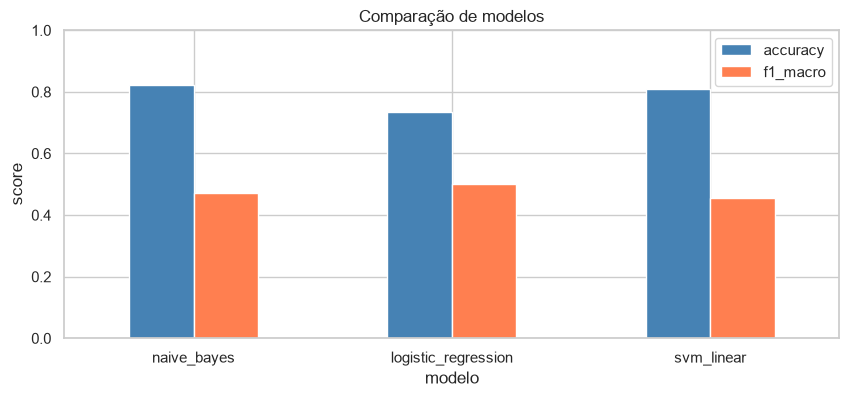

In [19]:
summary.set_index('modelo')[['accuracy', 'f1_macro']].plot(kind='bar', figsize=(10, 4), color=['steelblue', 'coral'])
plt.title('Comparação de modelos'); plt.ylabel('score'); plt.ylim(0, 1); plt.xticks(rotation=0); plt.show()

## 3. Matriz de confusão do melhor modelo

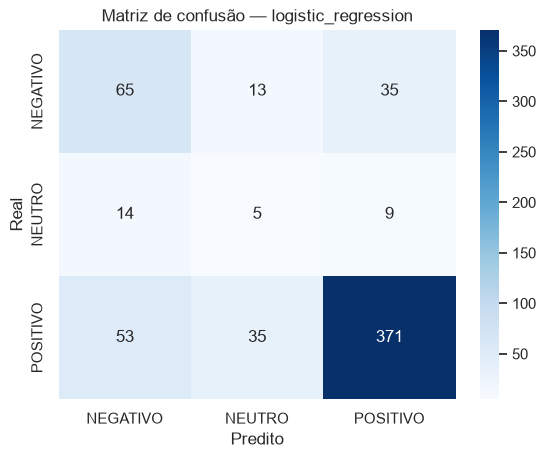

              precision  recall  f1-score  support
NEGATIVO          0.492   0.575     0.531  113.000
NEUTRO            0.094   0.179     0.123   28.000
POSITIVO          0.894   0.808     0.849  459.000
accuracy          0.735   0.735     0.735    0.735
macro avg         0.494   0.521     0.501  600.000
weighted avg      0.781   0.735     0.755  600.000


In [20]:
best_name = results['best_model']
best = next(r for r in results['results'] if r['name'] == best_name)
cm = pd.DataFrame(best['confusion'], index=LABELS, columns=LABELS)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusão — {best_name}')
plt.xlabel('Predito'); plt.ylabel('Real'); plt.show()
print(pd.DataFrame(best['report']).T.round(3))

## 4. Clusterização de reclamações

In [21]:
from src.models.clustering import run_clustering
clu = run_clustering(k=5)
print(json.dumps(clu, indent=2, ensure_ascii=False))

OperationalError: (psycopg2.OperationalError) could not translate host name "db" to address: Name or service not known

(Background on this error at: https://sqlalche.me/e/20/e3q8)

## 5. Modelo Pré-Treinado de NLP (Léxico PT)

Avalia um modelo baseado em léxico de sentimento em português — sem treino supervisionado, apenas conhecimento linguístico pré-existente. Representa a categoria **'modelos pré-treinados de NLP'** exigida no enunciado.

In [ ]:
from src.models.pretrained import evaluate_pretrained, predict_pretrained

# Avalia sobre todo o dataset
pretrained_result = evaluate_pretrained(df)
print(f"Accuracy : {pretrained_result['accuracy']:.4f}")
print(f"F1 Macro : {pretrained_result['f1_macro']:.4f}")

In [ ]:
# Comparação final: todos os modelos
all_results = results['results'] + [pretrained_result]

comparison = pd.DataFrame([
    {
        'modelo': r['name'],
        'accuracy': r['accuracy'],
        'f1_macro': r['f1_macro'],
    } for r in all_results
])

comparison = comparison.sort_values('f1_macro', ascending=False).reset_index(drop=True)
print('=== Ranking final de modelos ===')
print(comparison.to_string(index=False))

comparison.set_index('modelo')[['accuracy', 'f1_macro']].plot(
    kind='bar', figsize=(12, 5), color=['steelblue', 'coral']
)
plt.title('Comparação completa — todos os modelos (incluindo pré-treinado)')
plt.ylabel('score'); plt.ylim(0, 1); plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()

In [ ]:
# Teste manual do modelo pré-treinado
exemplos = [
    'Aplicativo excelente, muito rápido e fácil de usar!',
    'Horrível, trava toda hora e não abre mais depois da atualização',
    'Mais ou menos, poderia melhorar',
    'Não consigo entrar na minha conta, péssimo suporte',
    'Top demais, recomendo para todos!',
]

for ex in exemplos:
    r = predict_pretrained(ex)
    print(f"[{r['sentiment']:8s}] confiança={r['confidence']:.2f} | {ex[:60]}")

## 6. Conclusões finais

- **Modelo campeão supervisionado:** Regressão Logística (melhor F1 macro entre os treinados).
- **Modelo pré-treinado (léxico PT):** não requer dados rotulados, funciona out-of-the-box, mas tende a ter F1 menor por não se adaptar ao vocabulário específico do app.
- **Desbalanceamento:** classe NEUTRO (141 amostras vs 2297 POSITIVOS) é o principal limitador do F1 macro — `class_weight='balanced'` mitiga mas não elimina o problema.
- **K-Means (clustering):** identificou 4 temas recorrentes nas reclamações (qualidade/bugs, acesso/conta, propagandas, ruído).
- **Próximos passos possíveis:** coletar mais reviews NEUTROS; testar BERTimbau (BERT em PT) para ganho real de F1.